# Just Enough — Demand Forecasting MVP

## Project goal

Just Enough forecasts **daily demand for every menu item for the next 7 days**.

This notebook has four objectives:

1. Understand the restaurant sales data through EDA.
2. Build leakage-safe forecasting features.
3. Train and compare **LightGBM, XGBoost, and CatBoost**.
4. Select and save the best model for deployment.

### Important design principle

The competition-winning solution is used as inspiration, but this notebook prioritizes a **stable and realistic MVP**. In particular, validation must simulate the real product: predict the next 7 days using only information that would have been available at the forecast cutoff.


## Notebook structure

**Part A — EDA**
- Dataset structure
- Missing values and duplicates
- Sales distribution
- Restaurant and menu-item demand
- Category demand
- Daily / weekly / monthly seasonality
- Promotions, holidays and events
- Weather relationships

**Part B — Forecasting**
- Chronological validation
- Leakage-safe lag and rolling features
- Known future signals

**Part C — Model comparison**
- LightGBM
- XGBoost
- CatBoost
- wMAPE comparison

**Part D — Final model**
- Select the best model
- Train on all available training history
- Forecast the next 7 days
- Save deployment artifacts


In [1]:
# Install the ML libraries used in this notebook

%pip install xgboost catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Verify XGBoost and CatBoost

import xgboost
import catboost

print("XGBoost version:", xgboost.__version__)
print("CatBoost version:", catboost.__version__)

XGBoost version: 3.4.1
CatBoost version: 1.2.10


In [3]:
# Cell 1 — Imports

import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = r"D:\Competitions & Student activities\IEEE VICTORIS - AI powered apps\Datasets\2026 HAVI - NIU Hackathon - dataset\qsr_demand_dataset.csv"


### Cell 1 — Purpose

Import the libraries used throughout the notebook.

We keep the stack intentionally simple so the ML team can understand and maintain the notebook easily.


In [4]:
# Cell 2 — Load data

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(
    ["restaurant_id", "menu_item_id", "date"]
).reset_index(drop=True)

print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))


Rows: 1,369,500
Columns: 23


### Cell 2 — Purpose

Load the raw dataset and sort it chronologically by restaurant and menu item.

The target variable is `quantity`, representing the number of units sold.


In [5]:
# Cell 3 — Dataset overview

display(df.head())
display(df.dtypes.to_frame("dtype"))


,date,restaurant_id,restaurant_name,city,state,menu_item_id,menu_item_name,category,unit_price,quantity,...,month,year,avg_temp_f,precip_inches,precip_type,is_holiday,holiday_name,is_special_event,special_event_name,is_promotion
0,2021-01-01,R01,Downtown Chicago Grill,Chicago,IL,M01,Classic Cheeseburger,Burgers,6.99,75.0,...,1,2021,24.3,0.00,NaN,1,New Year's Day,0,NaN,0
1,2021-01-02,R01,Downtown Chicago Grill,Chicago,IL,M01,Classic Cheeseburger,Burgers,6.99,49.0,...,1,2021,27.8,0.16,Snow,0,NaN,0,NaN,0
2,2021-01-03,R01,Downtown Chicago Grill,Chicago,IL,M01,Classic Cheeseburger,Burgers,6.99,55.0,...,1,2021,24.6,0.00,NaN,0,NaN,0,NaN,0
3,2021-01-04,R01,Downtown Chicago Grill,Chicago,IL,M01,Classic Cheeseburger,Burgers,6.99,44.0,...,1,2021,20.5,0.00,NaN,0,NaN,0,NaN,0
4,2021-01-05,R01,Downtown Chicago Grill,Chicago,IL,M01,Classic Cheeseburger,Burgers,6.99,40.0,...,1,2021,24.8,0.01,Snow,0,NaN,0,NaN,0


,dtype
date,datetime64[ns]
restaurant_id,object
restaurant_name,object
city,object
state,object
menu_item_id,object
menu_item_name,object
category,object
unit_price,float64
quantity,float64


### Cell 3 — Purpose

Inspect the first records and data types.

This confirms which variables are dates, categorical identifiers, numerical signals, and the target.


In [6]:
# Cell 4 — Dataset dimensions and cardinality

print("Date range:")
print(df["date"].min().date(), "→", df["date"].max().date())

print("\nRestaurants:", df["restaurant_id"].nunique())
print("Menu items:", df["menu_item_id"].nunique())
print("Categories:", df["category"].nunique())
print("Unique dates:", df["date"].nunique())


Date range:
2021-01-01 → 2025-12-31

Restaurants: 15
Menu items: 50
Categories: 8
Unique dates: 1826


### Cell 4 — Purpose

Understand the scale of the forecasting problem.

The model is a **global model**: one model learns demand across restaurants and menu items instead of creating hundreds of separate models.


In [7]:
# Cell 5 — Duplicate check

duplicates = df.duplicated(
    ["date", "restaurant_id", "menu_item_id"]
).sum()

print("Duplicate restaurant-item-date records:", duplicates)


Duplicate restaurant-item-date records: 0


### Cell 5 — Purpose

Each restaurant-item-date should represent one demand observation.

Duplicate records could distort lag features and model training, so we check them before continuing.


In [8]:
# Cell 6 — Missing-value summary

missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing["missing_pct"] = missing["missing_count"] / len(df) * 100

display(missing)


,missing_count,missing_pct
special_event_name,1322250,96.549836
holiday_name,1322250,96.549836
precip_type,904350,66.035049
quantity,5475,0.399781
date,0,0.000000
is_weekend,0,0.000000
is_special_event,0,0.000000
is_holiday,0,0.000000
precip_inches,0,0.000000
avg_temp_f,0,0.000000


### Cell 6 — Purpose

Identify missing values.

We do not blindly fill every missing value. For forecasting, missing historical demand and missing context have different meanings and must be handled differently.


In [9]:
# Cell 7 — Target summary

display(df["quantity"].describe())

print("Zero-demand rows:", (df["quantity"] == 0).sum())
print("Negative-demand rows:", (df["quantity"] < 0).sum())


count    1.364025e+06
mean     2.537797e+01
std      1.736473e+01
min      0.000000e+00
25%      1.500000e+01
50%      2.100000e+01
75%      3.200000e+01
max      1.050000e+03
Name: quantity, dtype: float64

Zero-demand rows: 29043
Negative-demand rows: 0


### Cell 7 — Purpose

Understand the target distribution.

Restaurant demand is usually non-negative and often skewed: a small number of item-days can have much higher demand than typical days.


In [10]:
# Cell 8 — Daily total demand

daily_demand = (
    df.groupby("date")["quantity"]
      .sum()
      .reset_index()
)

display(daily_demand.head())


,date,quantity
0,2021-01-01,18961.0
1,2021-01-02,15891.0
2,2021-01-03,14215.0
3,2021-01-04,11895.0
4,2021-01-05,11637.0


### Cell 8 — Purpose

Aggregate all restaurant-item demand by day.

This gives us the overall demand pattern before looking at individual restaurants and items.


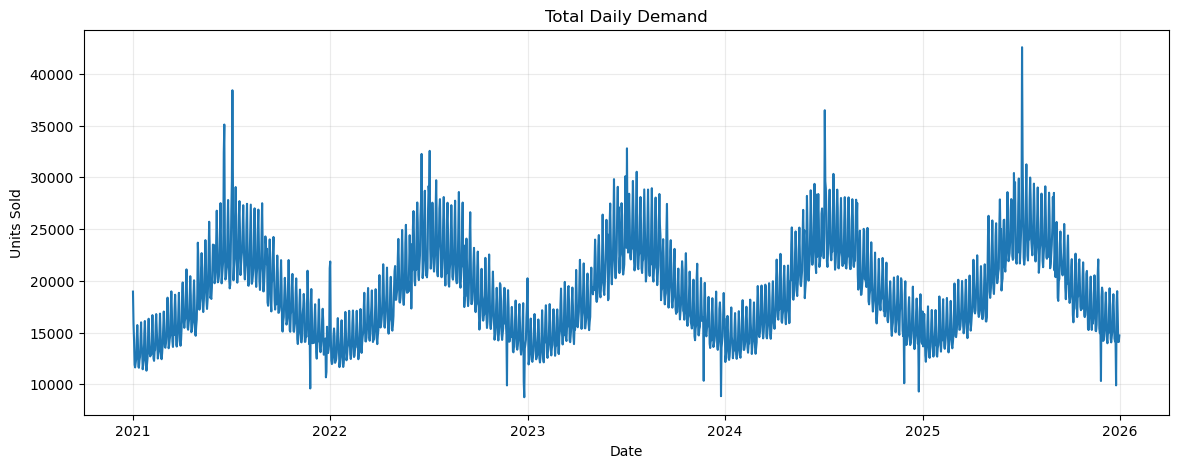

In [11]:
# Cell 9 — Daily demand trend

plt.figure(figsize=(14, 5))
plt.plot(daily_demand["date"], daily_demand["quantity"])
plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid(alpha=0.25)
plt.show()


### Cell 9 — Interpretation

This chart helps identify long-term trends, unusual periods, and possible structural changes in demand.

The model will later capture shorter-term and seasonal patterns through lag and calendar features.


In [12]:
# Cell 10 — Demand by restaurant

restaurant_demand = (
    df.groupby("restaurant_id")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

display(restaurant_demand.to_frame("total_quantity"))


,total_quantity
restaurant_id,
R01,3191305.0
R03,2930180.0
R07,2880743.0
R09,2804726.0
R02,2435188.0
R06,2432694.0
R15,2354319.0
R08,2324696.0
R05,2307562.0


### Cell 10 — Purpose

Measure total demand for each restaurant.

This is important because the competition metric is volume-weighted: high-volume restaurants and items have a larger effect on overall forecasting error.


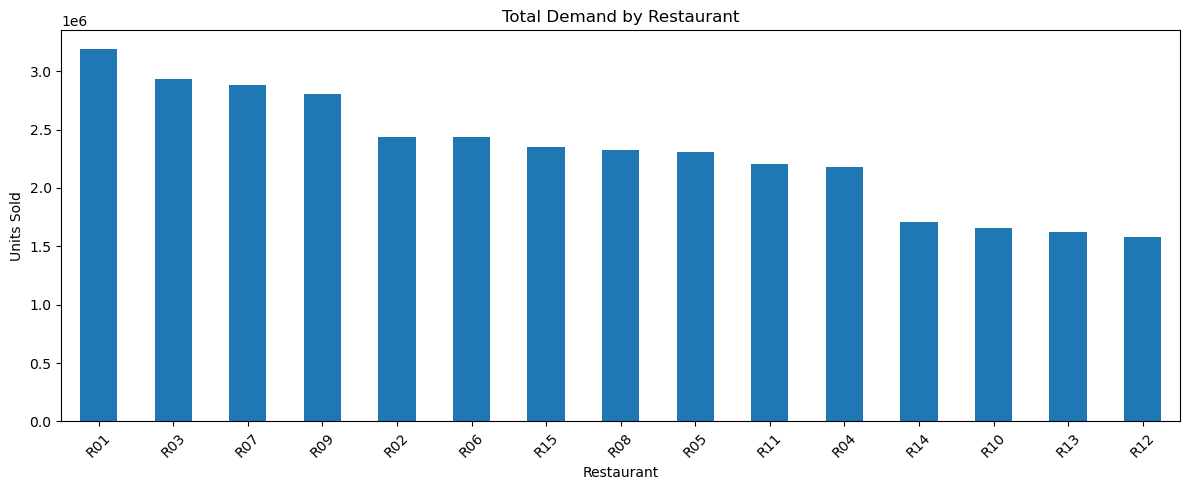

In [13]:
# Cell 11 — Restaurant demand chart

plt.figure(figsize=(12, 5))
restaurant_demand.plot(kind="bar")
plt.title("Total Demand by Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Cell 11 — Interpretation

Restaurants have different demand scales.

A global model therefore needs restaurant identity/context features so that it can learn these differences.


In [14]:
# Cell 12 — Top menu items

item_demand = (
    df.groupby("menu_item_id")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

display(item_demand.head(15).to_frame("total_quantity"))


,total_quantity
menu_item_id,
M23,1857850.0
M15,1583794.0
M01,1352685.0
M24,1238326.0
M11,1217587.0
M09,1098183.0
M43,1024560.0
M16,1008958.0
M02,960699.0


### Cell 12 — Purpose

Identify the highest-volume menu items.

This is useful both for understanding the business and for checking whether the model performs well on the items that contribute most to wMAPE.


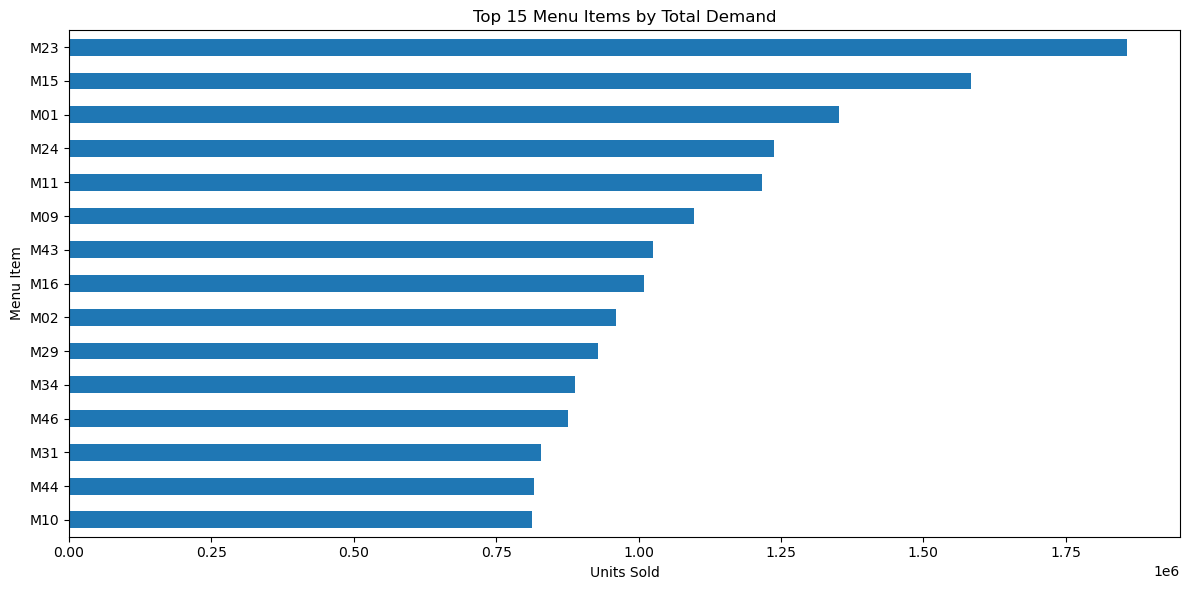

In [15]:
# Cell 13 — Top menu-item chart

top_items = item_demand.head(15)

plt.figure(figsize=(12, 6))
top_items.sort_values().plot(kind="barh")
plt.title("Top 15 Menu Items by Total Demand")
plt.xlabel("Units Sold")
plt.ylabel("Menu Item")
plt.tight_layout()
plt.show()


### Cell 13 — Interpretation

The demand distribution is not uniform across menu items.

This motivates volume-aware evaluation and, later, item-volume sample weighting experiments.


In [16]:
# Cell 14 — Demand by category

category_demand = (
    df.groupby("category")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

display(category_demand.to_frame("total_quantity"))


,total_quantity
category,
Drinks,7329084.0
Burgers,5669301.0
Sides,5176567.0
Chicken,4954058.0
Combos,3884475.0
Breakfast,3753862.0
Desserts,2639388.0
Specials,1209456.0


### Cell 14 — Purpose

Compare demand across product categories.

Category information can help a global model generalize between menu items with similar demand behavior.


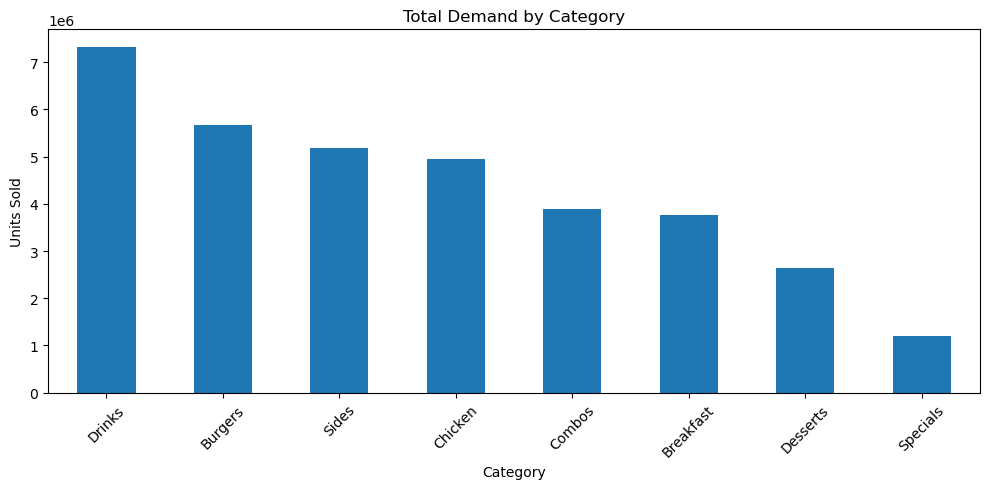

In [17]:
# Cell 15 — Category chart

plt.figure(figsize=(10, 5))
category_demand.plot(kind="bar")
plt.title("Total Demand by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Cell 15 — Interpretation

Category-level differences provide useful context for the forecasting model, especially for items with limited individual history.


In [18]:
# Cell 16 — Create calendar variables for EDA

df_eda = df.copy()

df_eda["year"] = df_eda["date"].dt.year
df_eda["month"] = df_eda["date"].dt.month
df_eda["day_of_week"] = df_eda["date"].dt.day_name()
df_eda["day_of_week_num"] = df_eda["date"].dt.dayofweek


### Cell 16 — Purpose

Create simple calendar variables for exploratory analysis.

These variables are also useful candidates for the final ML feature set.


In [19]:
# Cell 17 — Demand by day of week

dow_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

dow_demand = (
    df_eda.groupby("day_of_week")["quantity"]
          .mean()
          .reindex(dow_order)
)

display(dow_demand.to_frame("average_daily_item_quantity"))


,average_daily_item_quantity
day_of_week,
Monday,23.139311
Tuesday,22.176699
Wednesday,23.147817
Thursday,23.879415
Friday,27.811035
Saturday,30.232624
Sunday,27.253274


### Cell 17 — Purpose

Measure the average item-level demand by weekday.

Restaurant demand often changes significantly between weekdays and weekends, so weekly seasonality is a key forecasting signal.


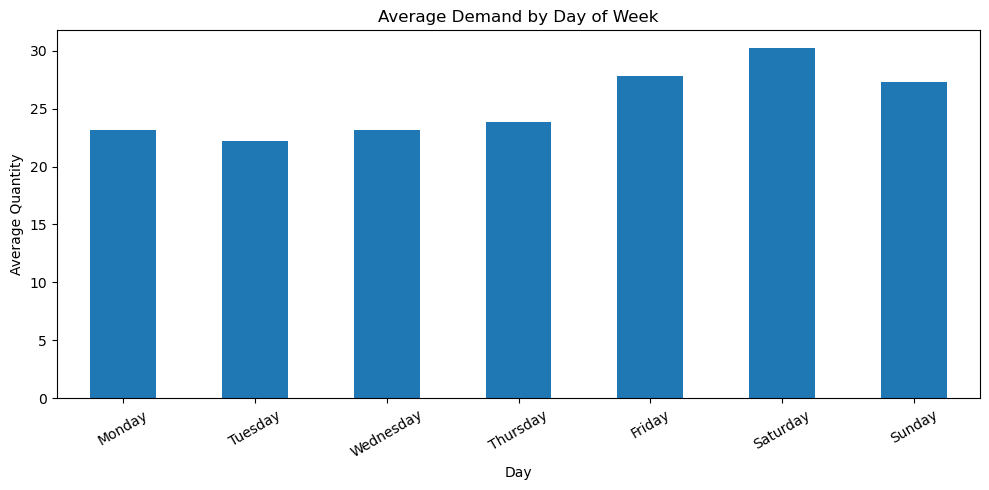

In [20]:
# Cell 18 — Day-of-week chart

plt.figure(figsize=(10, 5))
dow_demand.plot(kind="bar")
plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Quantity")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Cell 18 — Interpretation

A visible weekday pattern supports the use of day-of-week and same-weekday lag features.


In [21]:
# Cell 19 — Monthly demand

monthly_demand = (
    df_eda.groupby("month")["quantity"]
          .mean()
)

display(monthly_demand.to_frame("average_quantity"))


,average_quantity
month,
1,18.825326
2,19.710781
3,21.791870
4,23.881700
5,28.237539
6,31.849863
7,33.379593
8,31.199401
9,28.113257


### Cell 19 — Purpose

Check whether demand changes across the year.

The final model will use month and cyclic month features to represent annual seasonality.


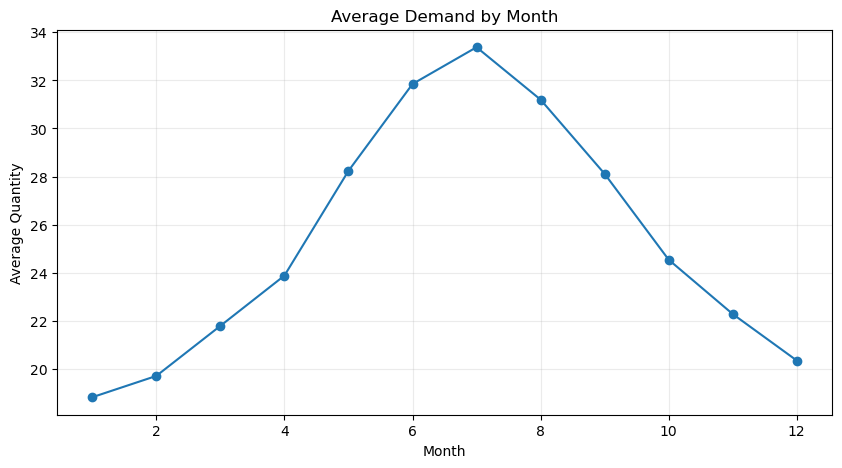

In [22]:
# Cell 20 — Monthly demand chart

plt.figure(figsize=(10, 5))
monthly_demand.plot(kind="line", marker="o")
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Quantity")
plt.grid(alpha=0.25)
plt.show()


### Cell 20 — Interpretation

Seasonal differences justify annual calendar features.

We do not assume that every restaurant or item has the same seasonal pattern; the model combines calendar variables with restaurant/item identity and historical demand.


In [23]:
# Cell 21 — Promotion analysis

promo_summary = (
    df_eda.groupby("is_promotion")["quantity"]
          .agg(["mean", "sum", "count"])
)

display(promo_summary)


,mean,sum,count
is_promotion,,,
0,25.302312,34120395.0,1348509
1,31.953854,495796.0,15516


### Cell 21 — Purpose

Compare demand on promotion versus non-promotion observations.

Promotions are a **known future signal** when they are planned in advance, so they can legitimately be provided to the model for future dates.


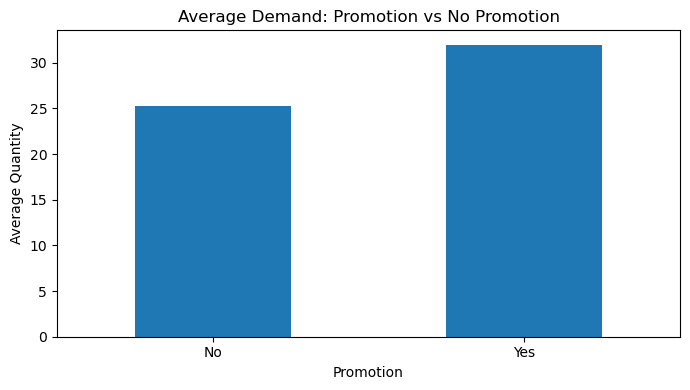

In [24]:
# Cell 22 — Promotion chart

promo_mean = promo_summary["mean"]

plt.figure(figsize=(7, 4))
promo_mean.plot(kind="bar")
plt.title("Average Demand: Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Quantity")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()


### Cell 22 — Interpretation

This does not prove that promotions cause the observed difference; it only shows that promotion status contains potentially useful predictive information.


In [25]:
# Cell 23 — Holiday analysis

holiday_summary = (
    df_eda.groupby("is_holiday")["quantity"]
          .agg(["mean", "sum", "count"])
)

display(holiday_summary)


,mean,sum,count
is_holiday,,,
0,25.323547,33350048.0,1316958
1,26.900865,1266143.0,47067


### Cell 23 — Purpose

Check whether holiday days behave differently from normal days.

For forecasting, the holiday calendar is supplied externally rather than guessed by the ML model.


In [26]:
# Cell 24 — Special-event analysis

event_summary = (
    df_eda.groupby("is_special_event")["quantity"]
          .agg(["mean", "sum", "count"])
)

display(event_summary)


,mean,sum,count
is_special_event,,,
0,24.845216,32720354.0,1316968
1,40.288097,1895837.0,47057


### Cell 24 — Purpose

Check whether special-event days have different demand.

Future special events should come from an ERP/calendar source or an administrator when no reliable external source exists.


In [27]:
# Cell 25 — Weather summary

weather_cols = [
    c for c in ["avg_temp_f", "precip_inches"]
    if c in df_eda.columns
]

display(df_eda[weather_cols].describe())


,avg_temp_f,precip_inches
count,1.369500e+06,1.369500e+06
mean,5.136719e+01,9.549398e-02
std,1.798457e+01,2.434710e-01
min,5.000000e-01,0.000000e+00
25%,3.520000e+01,0.000000e+00
50%,5.220000e+01,0.000000e+00
75%,6.830000e+01,6.000000e-02
max,8.480000e+01,3.180000e+00


### Cell 25 — Purpose

Inspect the weather variables available in the dataset.

In production, future weather should come from a weather forecast service using the restaurant's location.


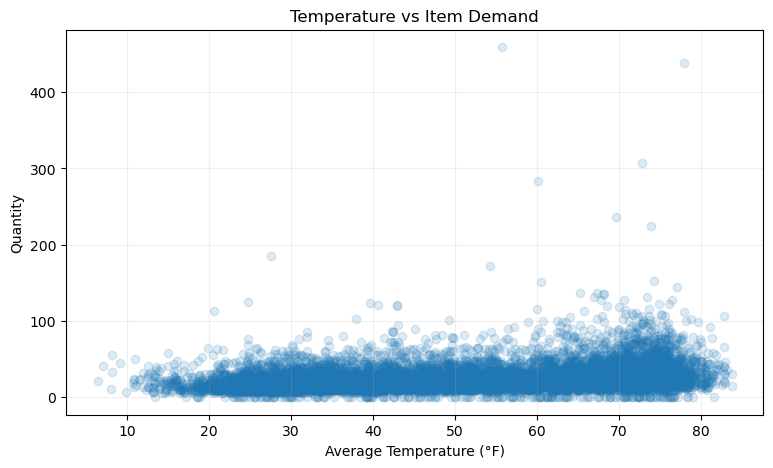

In [28]:
# Cell 26 — Temperature vs demand

sample = df_eda[
    ["avg_temp_f", "quantity"]
].dropna()

sample = sample.sample(
    min(10000, len(sample)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(9, 5))
plt.scatter(
    sample["avg_temp_f"],
    sample["quantity"],
    alpha=0.15
)
plt.title("Temperature vs Item Demand")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("Quantity")
plt.grid(alpha=0.2)
plt.show()


### Cell 26 — Interpretation

Weather may have nonlinear effects.

For example, demand might behave differently at very cold, moderate, and very hot temperatures. Tree-based models can learn such nonlinear relationships.


# Part B — Forecasting setup

The most important requirement is to evaluate the model as a **real 7-day forecasting system**.

We will never use future sales to create features.

For a forecast cutoff T:

```text
Known history: dates <= T
Forecast: T+1 ... T+7
```

The validation windows below simulate exactly this situation.


In [29]:
# Cell 27 — Define training period

TRAIN_END = pd.Timestamp("2025-09-30")

train_raw = df[
    df["date"] <= TRAIN_END
].copy()

future_raw = df[
    df["date"] > TRAIN_END
].copy()

print("Training:", train_raw["date"].min().date(), "→", train_raw["date"].max().date())
print("Future:", future_raw["date"].min().date(), "→", future_raw["date"].max().date())


Training: 2021-01-01 → 2025-09-30
Future: 2025-10-01 → 2025-12-31


### Cell 27 — Purpose

Separate confirmed historical demand from the final future period.

The future period is never used when calculating training target-derived features.


In [30]:
# Cell 28 — Feature engineering: calendar

def add_calendar_features(x):
    x = x.copy()

    x["year"] = x["date"].dt.year
    x["month"] = x["date"].dt.month
    x["day_of_month"] = x["date"].dt.day
    x["day_of_year"] = x["date"].dt.dayofyear
    x["week_of_year"] = x["date"].dt.isocalendar().week.astype(int)

    x["dow_sin"] = np.sin(2 * np.pi * x["day_of_week_num"] / 7)
    x["dow_cos"] = np.cos(2 * np.pi * x["day_of_week_num"] / 7)

    x["month_sin"] = np.sin(2 * np.pi * x["month"] / 12)
    x["month_cos"] = np.cos(2 * np.pi * x["month"] / 12)

    x["is_month_start"] = (
        x["day_of_month"] <= 3
    ).astype(int)

    x["is_month_end"] = (
        x["day_of_month"] >= 28
    ).astype(int)

    return x


### Cell 28 — Purpose

Create calendar features that are known before the forecast is made.

No target information is used here.


In [31]:
# Cell 29 — Feature engineering: weather

def add_weather_features(x):
    x = x.copy()

    temp = x["avg_temp_f"].fillna(
        x["avg_temp_f"].median()
    )

    precip = x["precip_inches"].fillna(0)

    x["is_rain"] = (
        x["precip_type"].fillna("") == "Rain"
    ).astype(int)

    x["is_snow"] = (
        x["precip_type"].fillna("") == "Snow"
    ).astype(int)

    x["is_precip"] = (precip > 0).astype(int)
    x["heavy_precip"] = (precip > 0.5).astype(int)

    x["temp_squared"] = temp ** 2
    x["temp_x_precip"] = temp * precip

    return x


### Cell 29 — Purpose

Transform weather into simple nonlinear signals.

In production, the values for future dates come from the weather forecast rather than actual future weather.


In [32]:
# Cell 30 — Feature engineering: future-signal interactions

def add_signal_features(x):
    x = x.copy()

    x["promo_x_weekend"] = (
        x["is_promotion"].fillna(0)
        * x["is_weekend"].fillna(0)
    )

    x["promo_x_holiday"] = (
        x["is_promotion"].fillna(0)
        * x["is_holiday"].fillna(0)
    )

    x["event_x_weekend"] = (
        x["is_special_event"].fillna(0)
        * x["is_weekend"].fillna(0)
    )

    return x


### Cell 30 — Purpose

Create interactions between future signals.

For example, a promotion during a weekend can have a different effect from the same promotion on a normal weekday.


In [33]:
# Cell 31 — Feature engineering: holiday distance

def add_holiday_distance(x):
    x = x.copy()

    holiday_dates = np.array(
        sorted(
            pd.to_datetime(
                x.loc[
                    x["is_holiday"].fillna(0).astype(int) == 1,
                    "date"
                ].unique()
            )
        )
    )

    if len(holiday_dates) == 0:
        x["days_to_holiday"] = 30
        x["days_since_holiday"] = 30
        return x

    dates = x["date"].values.astype("datetime64[D]")
    holidays = holiday_dates.astype("datetime64[D]")

    pos = np.searchsorted(holidays, dates)

    next_dist = np.full(len(x), 30, dtype=float)
    prev_dist = np.full(len(x), 30, dtype=float)

    valid_next = pos < len(holidays)
    next_dist[valid_next] = (
        holidays[pos[valid_next]] - dates[valid_next]
    ).astype("timedelta64[D]").astype(int)

    valid_prev = pos > 0
    prev_dist[valid_prev] = (
        dates[valid_prev] - holidays[pos[valid_prev] - 1]
    ).astype("timedelta64[D]").astype(int)

    x["days_to_holiday"] = next_dist
    x["days_since_holiday"] = prev_dist

    x["near_holiday"] = (
        x["days_to_holiday"] <= 3
    ).astype(int)

    x["holiday_week"] = (
        x["days_to_holiday"] <= 7
    ).astype(int)

    x["post_holiday"] = (
        x["days_since_holiday"] <= 2
    ).astype(int)

    return x


### Cell 31 — Purpose

Represent the effect of being close to a holiday.

These features are calculated from the holiday calendar, not from sales, so future holiday dates can be used safely.


In [34]:
# Cell 32 — Apply static features

train_feat = train_raw.copy()

train_feat = add_calendar_features(train_feat)
train_feat = add_weather_features(train_feat)
train_feat = add_signal_features(train_feat)
train_feat = add_holiday_distance(train_feat)

print("Columns after static feature engineering:", len(train_feat.columns))


Columns after static feature engineering: 46


### Cell 32 — Purpose

Combine the non-target feature transformations into the training dataset.


In [35]:
# Cell 33 — Feature engineering: historical lags

LAGS = [1, 2, 3, 7, 14, 28, 56, 364]

group_cols = [
    "restaurant_id",
    "menu_item_id"
]

group = train_feat.groupby(
    group_cols,
    sort=False
)["quantity"]

for lag in LAGS:
    train_feat[f"lag_{lag}"] = group.shift(lag)


### Cell 33 — Purpose

Create historical demand lags.

The 7-day lag is especially important for restaurants because it compares the current day with the same weekday one week earlier.

The 364-day lag provides approximately year-over-year information.


In [36]:
# Cell 34 — Feature engineering: same-weekday lags

for weeks in [1, 2, 3, 4]:
    train_feat[f"sdow_lag_{weeks}"] = group.shift(
        7 * weeks
    )


### Cell 34 — Purpose

Create same-weekday historical demand.

For example, when forecasting a Friday, `sdow_lag_1` represents the previous Friday.


In [37]:
# Cell 35 — Feature engineering: rolling statistics

shifted = group.shift(1)

for window in [7, 14, 28]:
    train_feat[f"rmean_{window}"] = (
        shifted.groupby(
            [
                train_feat["restaurant_id"],
                train_feat["menu_item_id"]
            ],
            sort=False
        )
        .transform(
            lambda s: s.rolling(
                window,
                min_periods=max(3, window // 2)
            ).mean()
        )
    )


### Cell 35 — Purpose

Calculate rolling averages using only previous observations.

The `shift(1)` is critical: it prevents today's actual quantity from entering today's feature values.


In [38]:
# Cell 36 — Rolling variability

for window in [7, 14, 28]:
    train_feat[f"rstd_{window}"] = (
        shifted.groupby(
            [
                train_feat["restaurant_id"],
                train_feat["menu_item_id"]
            ],
            sort=False
        )
        .transform(
            lambda s: s.rolling(
                window,
                min_periods=max(3, window // 2)
            ).std()
        )
    )


### Cell 36 — Purpose

Add demand volatility.

Two items can have the same average demand but very different variability; the rolling standard deviation helps the model distinguish them.


In [39]:
# Cell 37 — Trend feature

train_feat["trend_7_28"] = (
    train_feat["rmean_7"]
    / (train_feat["rmean_28"] + 1.0)
)


### Cell 37 — Purpose

Compare recent demand with the longer-term level.

A value above 1 generally indicates that recent demand is higher than the longer-term average.


In [40]:
# Cell 38 — Safe historical target encodings

def add_expanding_encoding(
    data,
    keys,
    output_name
):
    data = data.copy()

    data[output_name] = (
        data.groupby(keys, sort=False)["quantity"]
            .transform(
                lambda s: s.shift(1)
                          .expanding(min_periods=3)
                          .mean()
            )
    )

    return data


### Cell 38 — Purpose

Define a safe target-encoding helper.

Unlike a full-dataset `groupby().mean()`, this encoding uses only historical observations before the current date.


In [41]:
# Cell 39 — Item and restaurant encodings

train_feat = add_expanding_encoding(
    train_feat,
    ["menu_item_id"],
    "item_mean_enc"
)

train_feat = add_expanding_encoding(
    train_feat,
    ["restaurant_id"],
    "restaurant_mean_enc"
)


### Cell 39 — Purpose

Give the model historical demand context for each item and restaurant without leaking future targets.


In [42]:
# Cell 40 — Restaurant-item encoding

train_feat = add_expanding_encoding(
    train_feat,
    ["restaurant_id", "menu_item_id"],
    "ri_mean_enc"
)


### Cell 40 — Purpose

Capture the specific demand level of a menu item at a specific restaurant.

This is one of the most useful hierarchical signals for a global restaurant model.


In [43]:
# Cell 41 — Item seasonality encodings

train_feat = add_expanding_encoding(
    train_feat,
    ["menu_item_id", "day_of_week_num"],
    "item_dow_mean_enc"
)

train_feat = add_expanding_encoding(
    train_feat,
    ["menu_item_id", "month"],
    "item_month_mean_enc"
)


### Cell 41 — Purpose

Capture item-specific weekday and monthly behavior using only prior observations.


In [44]:
# Cell 42 — Restaurant seasonality encodings

train_feat = add_expanding_encoding(
    train_feat,
    ["restaurant_id", "day_of_week_num"],
    "restaurant_dow_mean_enc"
)

train_feat = add_expanding_encoding(
    train_feat,
    ["restaurant_id", "month"],
    "restaurant_month_mean_enc"
)


### Cell 42 — Purpose

Capture restaurant-specific seasonality.


In [45]:
# Cell 43 — Select model features

EXCLUDE = {
    "date",
    "quantity",
    "restaurant_id",
    "restaurant_name",
    "city",
    "state",
    "menu_item_id",
    "menu_item_name",
    "category",
    "day_of_week",
    "precip_type",
    "holiday_name",
    "special_event_name"
}

FEATURES = [
    c for c in train_feat.columns
    if c not in EXCLUDE
    and pd.api.types.is_numeric_dtype(train_feat[c])
]

train_feat[FEATURES] = train_feat[FEATURES].replace(
    [np.inf, -np.inf],
    np.nan
)

print("Number of features:", len(FEATURES))


Number of features: 59


### Cell 43 — Purpose

Create the final numerical feature matrix.

Categorical IDs are excluded from this first MVP feature matrix; their historical encodings and numeric identifiers are used instead.


# Part C — Model comparison

We compare three strong tabular ML models:

1. **LightGBM**
2. **XGBoost**
3. **CatBoost**

All models use the same training rows, features, chronological validation period, and wMAPE metric.

This makes the comparison fair and easy to explain.


In [46]:
# Cell 44 — wMAPE metric

def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Keep only rows where both actual and prediction are valid
    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if len(y_true) == 0:
        return np.nan

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(
        np.abs(y_true - y_pred)
    ) / denominator

### Cell 44 — Purpose

Implement weighted mean absolute percentage error.

Lower wMAPE is better.

For this problem, wMAPE is especially useful because high-volume demand contributes more to total forecasting error.


In [47]:
# Cell 45 — Chronological validation split

VAL_START = pd.Timestamp("2025-07-01")
VAL_END = pd.Timestamp("2025-07-07")

# Training: before validation period
train_mask = (
    (train_feat["date"] < VAL_START)
    & train_feat["quantity"].notna()
)

# Validation: selected 7-day period
val_mask = (
    (train_feat["date"] >= VAL_START)
    & (train_feat["date"] <= VAL_END)
    & train_feat["quantity"].notna()
)

X_train = train_feat.loc[train_mask, FEATURES].copy()
y_train = train_feat.loc[train_mask, "quantity"].astype(float).copy()

X_val = train_feat.loc[val_mask, FEATURES].copy()
y_val = train_feat.loc[val_mask, "quantity"].astype(float).copy()

# ---------------------------------------------------------
# Final safety check: remove invalid target values
# ---------------------------------------------------------

train_valid = np.isfinite(y_train.values)
val_valid = np.isfinite(y_val.values)

X_train = X_train.loc[train_valid].copy()
y_train = y_train.loc[train_valid].copy()

X_val = X_val.loc[val_valid].copy()
y_val = y_val.loc[val_valid].copy()

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))

print("\nTarget checks:")
print("NaN y_train:", y_train.isna().sum())
print("Inf y_train:", np.isinf(y_train).sum())

print("NaN y_val:", y_val.isna().sum())
print("Inf y_val:", np.isinf(y_val).sum())

print("\nTarget ranges:")
print("Minimum y_train:", y_train.min())
print("Maximum y_train:", y_train.max())
print("Minimum y_val:", y_val.min())
print("Maximum y_val:", y_val.max())

Training rows: 1226617
Validation rows: 5234

Target checks:
NaN y_train: 0
Inf y_train: 0
NaN y_val: 0
Inf y_val: 0

Target ranges:
Minimum y_train: 0.0
Maximum y_train: 1050.0
Minimum y_val: 0.0
Maximum y_val: 353.0


In [48]:
# Cell 45A — Training data sanity check

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nInvalid values in target:")
print("NaN:", y_train.isna().sum())
print("Inf:", np.isinf(y_train).sum())

print("\nTarget statistics:")
print(y_train.describe())

X_train shape: (1226617, 59)
y_train shape: (1226617,)

Invalid values in target:
NaN: 0
Inf: 0

Target statistics:
count    1.226617e+06
mean     2.512476e+01
std      1.718986e+01
min      0.000000e+00
25%      1.400000e+01
50%      2.100000e+01
75%      3.100000e+01
max      1.050000e+03
Name: quantity, dtype: float64


### Cell 45 — Purpose

Create a chronological 7-day validation window.

This is much closer to the actual Just Enough use case than a random train/test split.


In [49]:
# Cell 46 — Baseline: same weekday

baseline_val = train_feat.loc[
    val_mask,
    [
        "date",
        "restaurant_id",
        "menu_item_id",
        "quantity"
    ]
].copy()

history_lookup = train_feat.set_index(
    ["date", "restaurant_id", "menu_item_id"]
)["quantity"]

baseline_predictions = []

for row in baseline_val.itertuples(index=False):
    previous_date = row.date - pd.Timedelta(days=7)

    prediction = history_lookup.get(
        (
            previous_date,
            row.restaurant_id,
            row.menu_item_id
        ),
        np.nan
    )

    baseline_predictions.append(prediction)

baseline_val["prediction"] = baseline_predictions
baseline_val["prediction"] = baseline_val["prediction"].fillna(
    train_feat.loc[train_mask, "quantity"].median()
)

baseline_score = wmape(
    baseline_val["quantity"],
    baseline_val["prediction"]
)

print(f"Same-weekday baseline wMAPE: {baseline_score:.4f}")


Same-weekday baseline wMAPE: 0.2777


### Cell 46 — Purpose

Establish a simple business baseline.

The ML models must beat this baseline to justify their complexity.


In [50]:
# Cell 47 — Train LightGBM

import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    objective="mae",
    learning_rate=0.03,
    n_estimators=1200,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.5,
    random_state=RANDOM_STATE,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

lgb_pred = np.clip(
    lgb_model.predict(X_val),
    0,
    None
)

lgb_score = wmape(y_val, lgb_pred)

print(f"LightGBM wMAPE: {lgb_score:.4f}")


LightGBM wMAPE: 0.1485


### Cell 47 — Purpose

Train the first ML candidate.

LightGBM is fast, strong on tabular data, and relatively easy to deploy, making it a good MVP choice.


In [51]:
# Cell 48 — Train XGBoost

import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_estimators=1200,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_model.fit(
    X_train,
    y_train,
    verbose=False
)

xgb_pred = np.clip(
    xgb_model.predict(X_val),
    0,
    None
)

xgb_score = wmape(y_val, xgb_pred)

print(f"XGBoost wMAPE: {xgb_score:.4f}")


XGBoost wMAPE: 0.1495


### Cell 48 — Purpose

Train a second gradient-boosting model.

XGBoost often makes somewhat different errors from LightGBM, which is useful if an ensemble is considered later.


In [52]:
# Cell 49 — Train CatBoost

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    loss_function="MAE",
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,
    iterations=1200,
    random_seed=RANDOM_STATE,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train
)

cat_pred = np.clip(
    cat_model.predict(X_val),
    0,
    None
)

cat_score = wmape(y_val, cat_pred)

print(f"CatBoost wMAPE: {cat_score:.4f}")


CatBoost wMAPE: 0.1494


### Cell 49 — Purpose

Train the third model.

CatBoost is another strong gradient-boosting implementation and provides model diversity for comparison.


In [53]:
# Cell 50 — Compare model scores

scores = pd.DataFrame({
    "Model": [
        "Same-weekday baseline",
        "LightGBM",
        "XGBoost",
        "CatBoost"
    ],
    "wMAPE": [
        baseline_score,
        lgb_score,
        xgb_score,
        cat_score
    ]
}).sort_values("wMAPE")

display(scores)


,Model,wMAPE
1,LightGBM,0.148497
3,CatBoost,0.149366
2,XGBoost,0.149497
0,Same-weekday baseline,0.277688


### Cell 50 — Interpretation

The lowest wMAPE is the best result on this validation window.

We do not choose a model based on complexity or popularity. We choose it based on **out-of-time forecasting performance**.


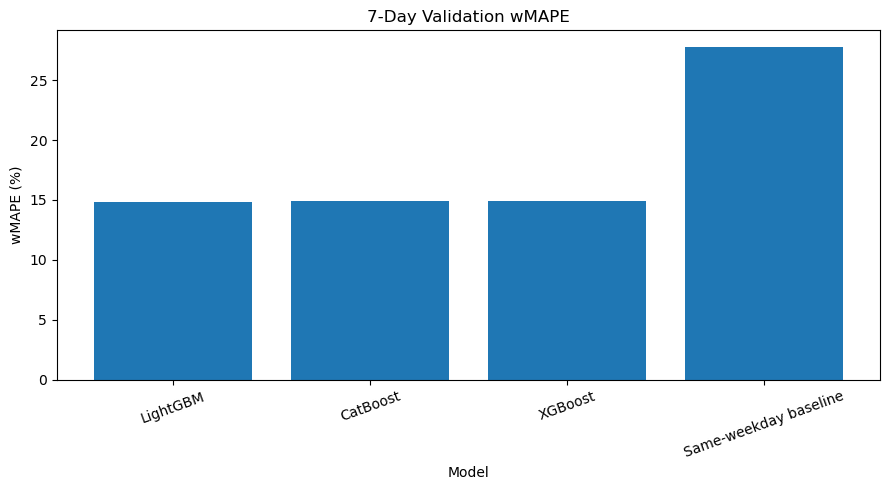

In [54]:
# Cell 51 — Model comparison chart

plt.figure(figsize=(9, 5))

plt.bar(
    scores["Model"],
    scores["wMAPE"] * 100
)

plt.title("7-Day Validation wMAPE")
plt.xlabel("Model")
plt.ylabel("wMAPE (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Cell 51 — Judge-facing interpretation

This chart answers a simple question:

> Which approach predicts unseen future demand most accurately?

Lower bars are better because wMAPE is an error metric.


# Part D — Final model selection

For the MVP, we select the best individual model from the validation experiment.

We do **not** automatically ensemble the three models. An ensemble is only justified if it consistently improves the score across multiple historical 7-day backtests.


In [55]:
# Cell 52 — Select best model

model_objects = {
    "LightGBM": lgb_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model
}

ml_scores = {
    "LightGBM": lgb_score,
    "XGBoost": xgb_score,
    "CatBoost": cat_score
}

best_model_name = min(
    ml_scores,
    key=ml_scores.get
)

best_model = model_objects[best_model_name]

print("Best MVP model:", best_model_name)
print("Validation wMAPE:", f"{ml_scores[best_model_name]:.4f}")


Best MVP model: LightGBM
Validation wMAPE: 0.1485


### Cell 52 — Purpose

Select the best-performing individual model.

If two models are very close, we can prefer the simpler/faster model for the MVP and revisit an ensemble after the system is stable.


In [56]:
# Cell 53 — Feature importance from the selected model

if best_model_name == "LightGBM":
    importance_values = best_model.feature_importances_
elif best_model_name == "XGBoost":
    importance_values = best_model.feature_importances_
else:
    importance_values = best_model.get_feature_importance()

feature_importance = (
    pd.Series(
        importance_values,
        index=FEATURES
    )
    .sort_values(ascending=False)
)

display(
    feature_importance.head(20).to_frame("importance")
)


,importance
ri_mean_enc,5344
item_month_mean_enc,4387
avg_temp_f,3463
lag_364,3141
unit_price,2877
rmean_28,2781
lag_1,2724
day_of_year,2670
item_mean_enc,2551
rmean_14,2546


### Cell 53 — Purpose

Inspect which features the selected model uses most.

This provides useful interpretability for the team and judges without claiming that feature importance proves causality.


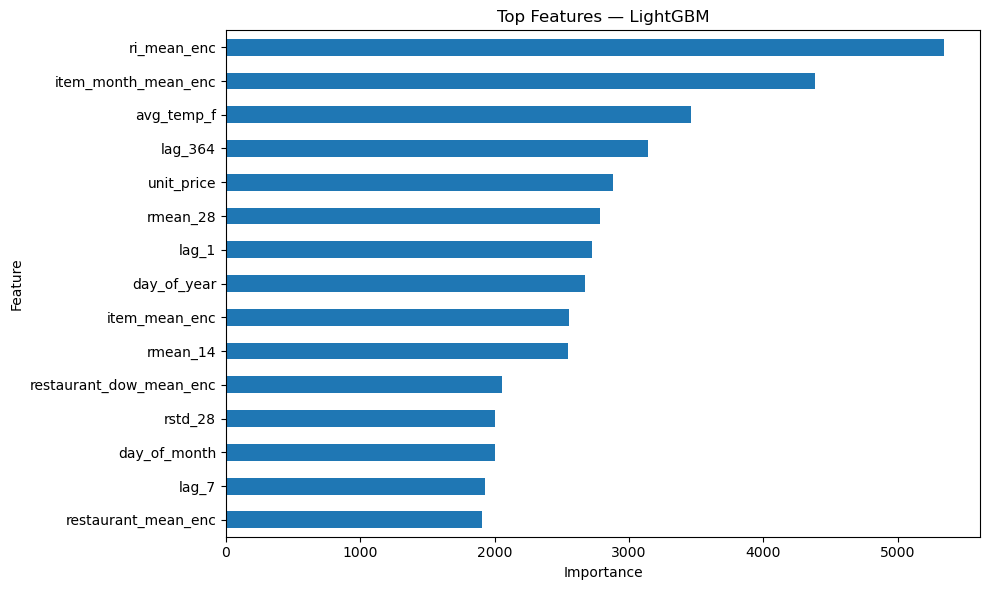

In [57]:
# Cell 54 — Feature importance chart

top_importance = feature_importance.head(15).sort_values()

plt.figure(figsize=(10, 6))
top_importance.plot(kind="barh")
plt.title(f"Top Features — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Cell 54 — Interpretation

The strongest features should primarily reflect historical demand, seasonality, restaurant/item behavior, and known future context.

If unexpected leakage-prone features dominate, stop and investigate before deployment.


# Part E — Final training

The final model is now retrained using **all confirmed historical data up to 2025-09-30**.

After model selection, the validation window is no longer needed for training.

The final model is then used to produce future predictions.


In [58]:
# Cell 55 — Prepare final training data

final_train = train_feat.copy()

final_train = final_train.dropna(
    subset=["lag_1", "lag_7", "rmean_7"]
).copy()

X_final = final_train[FEATURES]
y_final = final_train["quantity"].astype(float)

print("Final training rows:", len(final_train))


Final training rows: 1285008


### Cell 55 — Purpose

Prepare all confirmed historical observations that have enough history to calculate the core lag features.


In [59]:
# Cell 56 — Final LightGBM training

final_lgb = lgb.LGBMRegressor(
    objective="mae",
    learning_rate=0.03,
    n_estimators=1200,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.5,
    random_state=RANDOM_STATE,
    verbosity=-1
)


### Cell 56 — Purpose

Create the final LightGBM configuration.

The model is retrained below only if LightGBM was selected as the best MVP model.


In [60]:
# Cell 57 — Final model training

if best_model_name == "LightGBM":
    final_model = final_lgb

elif best_model_name == "XGBoost":
    final_model = xgb.XGBRegressor(
        objective="reg:absoluteerror",
        learning_rate=0.03,
        max_depth=8,
        min_child_weight=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_estimators=1200,
        random_state=RANDOM_STATE,
        verbosity=0
    )

elif best_model_name == "CatBoost":
    final_model = CatBoostRegressor(
        loss_function="MAE",
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=3,
        iterations=1200,
        random_seed=RANDOM_STATE,
        verbose=False
    )

final_model.fit(
    X_final,
    y_final
)

print("Final model trained:", best_model_name)


Final model trained: LightGBM


### Cell 57 — Purpose

Train the selected model on the complete historical training period.

This is the model that will be saved for inference.


# Part F — Deployment interface

The backend should not need to understand the research notebook.

The deployed ML component should expose one simple operation:

```text
forecast_next_7_days(restaurant_id, forecast_start)
```

The backend supplies historical data and known future context. The ML layer calculates the lag/rolling features and returns menu-item demand.


In [61]:
# Cell 58 — Save model and configuration

ARTIFACT_DIR = "just_enough_ml_artifacts"

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

joblib.dump(
    final_model,
    os.path.join(
        ARTIFACT_DIR,
        "demand_model.joblib"
    )
)

config = {
    "model_name": best_model_name,
    "target": "quantity",
    "forecast_horizon_days": 7,
    "train_end": str(TRAIN_END.date()),
    "features": FEATURES,
    "lags": LAGS,
    "rolling_windows": [7, 14, 28],
    "same_weekday_lags": [1, 2, 3, 4],
    "random_state": RANDOM_STATE
}

with open(
    os.path.join(
        ARTIFACT_DIR,
        "model_config.json"
    ),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        config,
        f,
        indent=2
    )

print("Artifacts saved to:", ARTIFACT_DIR)


Artifacts saved to: just_enough_ml_artifacts


### Cell 58 — Purpose

Save the trained model and configuration.

The configuration is important because the backend/inference environment must use the **same feature list and preprocessing logic** as training.


In [62]:
# Cell 59 — Deployment output schema

deployment_schema = pd.DataFrame({
    "field": [
        "date",
        "restaurant_id",
        "menu_item_id",
        "predicted_quantity"
    ],
    "type": [
        "date",
        "string",
        "string",
        "non-negative number"
    ]
})

display(deployment_schema)


,field,type
0,date,date
1,restaurant_id,string
2,menu_item_id,string
3,predicted_quantity,non-negative number


### Cell 59 — Backend contract

The ML output should be simple:

| Field | Meaning |
|---|---|
| `date` | Forecast date |
| `restaurant_id` | Restaurant |
| `menu_item_id` | Menu item |
| `predicted_quantity` | Expected units sold |

The frontend should display these results; it should not calculate ML features.


# Final MVP checklist

Before deployment, verify:

- **No random train/test split**
- **No future quantity in features**
- **Rolling features use `shift(1)`**
- **Target encodings use only prior observations**
- **Model beats the same-weekday baseline**
- **All three models were compared**
- **The final model is selected using validation performance**
- **Future promotions/holidays/events are supplied by the backend**
- **Future weather comes from a forecast service**
- **The model returns 7 days × menu items**
- **Ingredient quantities are calculated separately through the recipe/BOM layer**

## Production architecture

```text
POS / ERP
   ↓
Backend database
   ↓
Known future signals + weather
   ↓
ML feature engineering
   ↓
Best trained model
   ↓
7-day menu-item forecast
   ↓
Recipe / BOM calculation
   ↓
Ingredient requirements
   ↓
Frontend dashboard
```


> Just Enough does not ask restaurant managers to manually calculate demand. It combines historical sales with known future signals such as promotions, holidays, events, and weather forecasts, then uses a leakage-safe machine-learning pipeline to predict demand for every menu item over the next seven days.


In [63]:
from pathlib import Path
import os

print("Current working directory:")
print(os.getcwd())

print("\nLooking for ML artifacts...")

artifact_dir = Path("just_enough_ml_artifacts")

if artifact_dir.exists():
    print("\nFOUND!")
    print("Location:")
    print(artifact_dir.resolve())

    print("\nFiles inside:")
    for file in artifact_dir.iterdir():
        print(" -", file.name)
else:
    print("\nArtifact folder was NOT found.")

Current working directory:
C:\Users\hossa\ML_projects

Looking for ML artifacts...

FOUND!
Location:
C:\Users\hossa\ML_projects\just_enough_ml_artifacts

Files inside:
 - demand_model.joblib
 - model_config.json


In [64]:
# STEP 2 — Verify the saved model

import joblib
from pathlib import Path

artifact_dir = Path("just_enough_ml_artifacts")

model_path = artifact_dir / "demand_model.joblib"
config_path = artifact_dir / "model_config.json"

# Load the saved model
loaded_model = joblib.load(model_path)

print("Model loaded successfully!")
print("Model type:", type(loaded_model))

# Load the configuration
import json

with open(config_path, "r") as f:
    model_config = json.load(f)

print("\nModel configuration:")
print(json.dumps(model_config, indent=2))

Model loaded successfully!
Model type: <class 'lightgbm.sklearn.LGBMRegressor'>

Model configuration:
{
  "model_name": "LightGBM",
  "target": "quantity",
  "forecast_horizon_days": 7,
  "train_end": "2025-09-30",
  "features": [
    "unit_price",
    "day_of_week_num",
    "is_weekend",
    "month",
    "year",
    "avg_temp_f",
    "precip_inches",
    "is_holiday",
    "is_special_event",
    "is_promotion",
    "day_of_month",
    "day_of_year",
    "week_of_year",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "is_month_start",
    "is_month_end",
    "is_rain",
    "is_snow",
    "is_precip",
    "heavy_precip",
    "temp_squared",
    "temp_x_precip",
    "promo_x_weekend",
    "promo_x_holiday",
    "event_x_weekend",
    "days_to_holiday",
    "days_since_holiday",
    "near_holiday",
    "holiday_week",
    "post_holiday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_56",
    "lag_364",
    "sdow_lag_1",
    "s

In [65]:
# STEP 3 — Test the saved model on validation data

# Make predictions using the SAVED model
loaded_pred = loaded_model.predict(X_val)

# Make sure demand predictions cannot be negative
loaded_pred = np.clip(loaded_pred, 0, None)

print("Number of predictions:", len(loaded_pred))
print("NaN predictions:", np.isnan(loaded_pred).sum())
print("Infinite predictions:", np.isinf(loaded_pred).sum())
print("Negative predictions:", (loaded_pred < 0).sum())

print("\nFirst 10 predictions:")
print(loaded_pred[:10])

Number of predictions: 5234
NaN predictions: 0
Infinite predictions: 0
Negative predictions: 0

First 10 predictions:
[ 78.08386514  82.81173182 136.94151224 188.96305343 153.84429123
 103.44643951  85.31226645  56.86423042  62.26189262  89.52260041]


In [67]:
# STEP 4 — Create a user-facing forecast preview

# Get identifiers and dates from the original validation dataframe
forecast_preview = train_feat.loc[
    X_val.index,
    ["date", "restaurant_id", "menu_item_id"]
].copy()

# Add the saved model predictions
forecast_preview["predicted_quantity"] = np.rint(
    loaded_pred
).astype(int)

# Add menu item names
item_names = train_feat[
    ["menu_item_id", "menu_item_name"]
].drop_duplicates("menu_item_id")

forecast_preview = forecast_preview.merge(
    item_names,
    on="menu_item_id",
    how="left"
)

# Arrange columns for the restaurant user
forecast_preview = forecast_preview[
    [
        "date",
        "restaurant_id",
        "menu_item_id",
        "menu_item_name",
        "predicted_quantity"
    ]
]

# Display the first 20 predictions
forecast_preview.head(20)

,date,restaurant_id,menu_item_id,menu_item_name,predicted_quantity
0,2025-07-01,R01,M01,Classic Cheeseburger,78
1,2025-07-02,R01,M01,Classic Cheeseburger,83
2,2025-07-03,R01,M01,Classic Cheeseburger,137
3,2025-07-04,R01,M01,Classic Cheeseburger,189
4,2025-07-05,R01,M01,Classic Cheeseburger,154
5,2025-07-06,R01,M01,Classic Cheeseburger,103
6,2025-07-07,R01,M01,Classic Cheeseburger,85
7,2025-07-01,R01,M02,Double Bacon Burger,57
8,2025-07-02,R01,M02,Double Bacon Burger,62
9,2025-07-03,R01,M02,Double Bacon Burger,90


In [68]:
# STEP 5 — Calculate prediction errors

evaluation_df = train_feat.loc[
    X_val.index,
    ["date", "restaurant_id", "menu_item_id", "menu_item_name", "quantity"]
].copy()

evaluation_df["predicted_quantity"] = loaded_pred

evaluation_df["error"] = (
    evaluation_df["quantity"]
    - evaluation_df["predicted_quantity"]
)

evaluation_df["absolute_error"] = (
    evaluation_df["error"].abs()
)

evaluation_df["absolute_percentage_error"] = (
    evaluation_df["absolute_error"]
    / evaluation_df["quantity"].replace(0, np.nan)
)

evaluation_df.head(20)

,date,restaurant_id,menu_item_id,menu_item_name,quantity,predicted_quantity,error,absolute_error,absolute_percentage_error
1642,2025-07-01,R01,M01,Classic Cheeseburger,67.0,78.083865,-11.083865,11.083865,0.165431
1643,2025-07-02,R01,M01,Classic Cheeseburger,96.0,82.811732,13.188268,13.188268,0.137378
1644,2025-07-03,R01,M01,Classic Cheeseburger,142.0,136.941512,5.058488,5.058488,0.035623
1645,2025-07-04,R01,M01,Classic Cheeseburger,188.0,188.963053,-0.963053,0.963053,0.005123
1646,2025-07-05,R01,M01,Classic Cheeseburger,179.0,153.844291,25.155709,25.155709,0.140535
1647,2025-07-06,R01,M01,Classic Cheeseburger,125.0,103.446440,21.553560,21.553560,0.172428
1648,2025-07-07,R01,M01,Classic Cheeseburger,62.0,85.312266,-23.312266,23.312266,0.376004
3468,2025-07-01,R01,M02,Double Bacon Burger,65.0,56.864230,8.135770,8.135770,0.125166
3469,2025-07-02,R01,M02,Double Bacon Burger,54.0,62.261893,-8.261893,8.261893,0.152998
3470,2025-07-03,R01,M02,Double Bacon Burger,93.0,89.522600,3.477400,3.477400,0.037391


In [69]:
# STEP 6 — Calculate the practical prediction range

# Remove rows where percentage error cannot be calculated
valid_errors = evaluation_df[
    evaluation_df["absolute_percentage_error"].notna()
].copy()

# Calculate typical relative error levels
error_p50 = valid_errors["absolute_percentage_error"].quantile(0.50)
error_p80 = valid_errors["absolute_percentage_error"].quantile(0.80)

print("Median absolute percentage error:", f"{error_p50:.2%}")
print("80th percentile absolute percentage error:", f"{error_p80:.2%}")

# Use the 80th percentile as the practical uncertainty level
range_error = error_p80

# Prevent an excessively wide range
range_error = min(range_error, 0.50)

print("Error used for likely range:", f"{range_error:.2%}")

Median absolute percentage error: 10.04%
80th percentile absolute percentage error: 19.16%
Error used for likely range: 19.16%


In [70]:
# STEP 7 — Add recommended quantity and likely range

user_forecast = forecast_preview.copy()

# Recommended quantity
user_forecast["recommended_quantity"] = (
    user_forecast["predicted_quantity"]
).astype(int)

# Calculate likely range
user_forecast["likely_min"] = np.floor(
    user_forecast["recommended_quantity"] * (1 - range_error)
).astype(int)

user_forecast["likely_max"] = np.ceil(
    user_forecast["recommended_quantity"] * (1 + range_error)
).astype(int)

# Demand cannot be negative
user_forecast["likely_min"] = (
    user_forecast["likely_min"].clip(lower=0)
)

# Keep only the information useful to the restaurant user
user_forecast = user_forecast[
    [
        "date",
        "restaurant_id",
        "menu_item_id",
        "menu_item_name",
        "recommended_quantity",
        "likely_min",
        "likely_max"
    ]
]

user_forecast.head(20)

,date,restaurant_id,menu_item_id,menu_item_name,recommended_quantity,likely_min,likely_max
0,2025-07-01,R01,M01,Classic Cheeseburger,78,63,93
1,2025-07-02,R01,M01,Classic Cheeseburger,83,67,99
2,2025-07-03,R01,M01,Classic Cheeseburger,137,110,164
3,2025-07-04,R01,M01,Classic Cheeseburger,189,152,226
4,2025-07-05,R01,M01,Classic Cheeseburger,154,124,184
5,2025-07-06,R01,M01,Classic Cheeseburger,103,83,123
6,2025-07-07,R01,M01,Classic Cheeseburger,85,68,102
7,2025-07-01,R01,M02,Double Bacon Burger,57,46,68
8,2025-07-02,R01,M02,Double Bacon Burger,62,50,74
9,2025-07-03,R01,M02,Double Bacon Burger,90,72,108


In [71]:
# STEP 8A — Inspect available features for explanations

explanation_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rmean_7",
    "rmean_28",
    "sdow_lag_1",
    "sdow_lag_2",
    "is_promotion",
    "is_holiday",
    "is_special_event",
    "avg_temp_f",
    "is_rain",
    "is_snow",
    "month"
]

available_explanation_features = [
    col for col in explanation_features
    if col in train_feat.columns
]

print("Available explanation features:")
print(available_explanation_features)

Available explanation features:
['lag_1', 'lag_7', 'lag_14', 'rmean_7', 'rmean_28', 'sdow_lag_1', 'sdow_lag_2', 'is_promotion', 'is_holiday', 'is_special_event', 'avg_temp_f', 'is_rain', 'is_snow', 'month']


In [72]:
# STEP 8B — Generate business-friendly forecast explanations

def generate_explanation(row):
    reasons = []

    # 1. Recent demand trend
    if (
        pd.notna(row.get("rmean_7"))
        and pd.notna(row.get("rmean_28"))
    ):
        if row["rmean_7"] > row["rmean_28"] * 1.10:
            reasons.append("Recent demand is above the longer-term average.")
        elif row["rmean_7"] < row["rmean_28"] * 0.90:
            reasons.append("Recent demand is below the longer-term average.")

    # 2. Same-weekday pattern
    if (
        pd.notna(row.get("sdow_lag_1"))
        and pd.notna(row.get("rmean_28"))
    ):
        if row["sdow_lag_1"] > row["rmean_28"] * 1.10:
            reasons.append("This weekday has recently shown stronger demand.")
        elif row["sdow_lag_1"] < row["rmean_28"] * 0.90:
            reasons.append("This weekday has recently shown weaker demand.")

    # 3. Promotion
    if row.get("is_promotion", 0) == 1:
        reasons.append("A promotion is active on this date.")

    # 4. Holiday
    if row.get("is_holiday", 0) == 1:
        reasons.append("A holiday is affecting this date.")

    # 5. Special event
    if row.get("is_special_event", 0) == 1:
        reasons.append("A special event is scheduled for this date.")

    # 6. Weather
    if row.get("is_rain", 0) == 1:
        reasons.append("Rainy weather is expected.")

    if row.get("is_snow", 0) == 1:
        reasons.append("Snowy weather is expected.")

    # 7. Fallback
    if not reasons:
        reasons.append("The forecast is mainly based on historical demand patterns.")

    return reasons

In [73]:
# STEP 8C — Add explanations to the forecast

# Get the feature values for each validation prediction
explanation_data = train_feat.loc[
    X_val.index
].copy()

# Generate explanations
explanations = explanation_data.apply(
    generate_explanation,
    axis=1
)

# Add explanations to the user forecast
user_forecast["reasons"] = explanations.values

# Display the result
user_forecast[
    [
        "date",
        "menu_item_name",
        "recommended_quantity",
        "likely_min",
        "likely_max",
        "reasons"
    ]
].head(20)

,date,menu_item_name,recommended_quantity,likely_min,likely_max,reasons
0,2025-07-01,Classic Cheeseburger,78,63,93,[This weekday has recently shown weaker demand.]
1,2025-07-02,Classic Cheeseburger,83,67,99,[This weekday has recently shown weaker demand.]
2,2025-07-03,Classic Cheeseburger,137,110,164,[A special event is scheduled for this date.]
3,2025-07-04,Classic Cheeseburger,189,152,226,[Recent demand is above the longer-term averag...
4,2025-07-05,Classic Cheeseburger,154,124,184,[Recent demand is above the longer-term averag...
5,2025-07-06,Classic Cheeseburger,103,83,123,[Recent demand is above the longer-term average.]
6,2025-07-07,Classic Cheeseburger,85,68,102,[Recent demand is above the longer-term averag...
7,2025-07-01,Double Bacon Burger,57,46,68,[The forecast is mainly based on historical de...
8,2025-07-02,Double Bacon Burger,62,50,74,[The forecast is mainly based on historical de...
9,2025-07-03,Double Bacon Burger,90,72,108,[A special event is scheduled for this date.]
